In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Importe le csv des Tenracs et calcule leur nombre en avance
bd = pd.read_csv('./cartes.csv')
clubs = bd["nomClub"].value_counts()
clubs = clubs[:30]

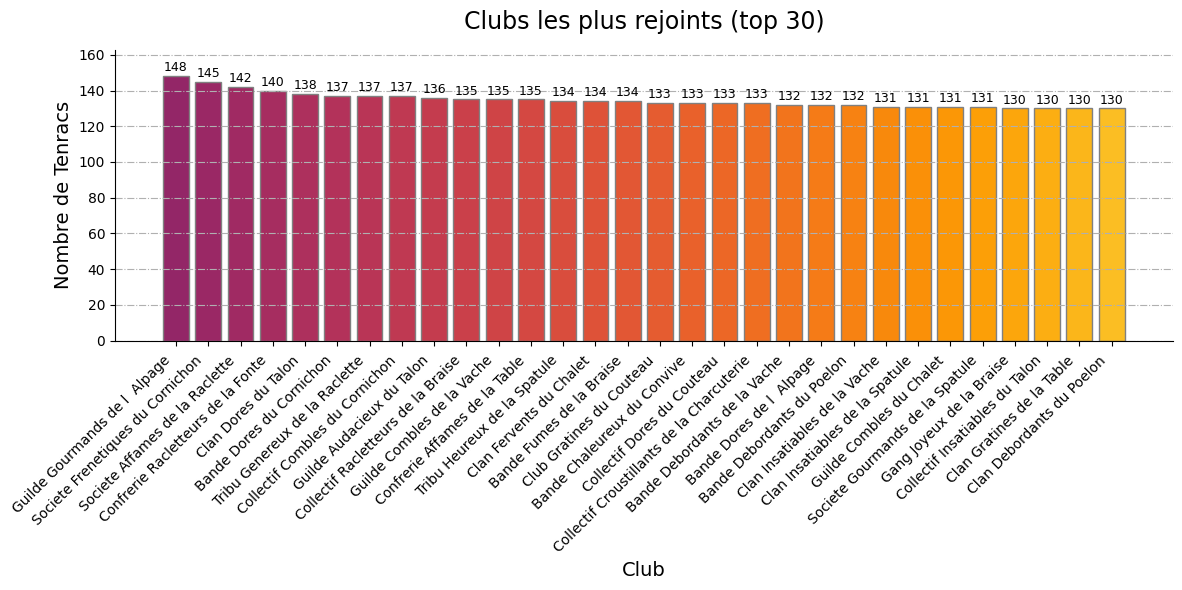

In [22]:
# Génère des couleurs uniformément depuis la palette "inferno"
couleur = plt.cm.inferno(np.linspace(0.4, 0.85, len(clubs)))

# Crée la figure et les axes
fig, ax = plt.subplots(figsize=(12, 6))
# Dessine les barres : index = noms des grades, values = effectifs
bars = ax.bar(clubs.index, clubs.values, color=couleur, edgecolor='grey')

# Pour chaque barre, affiche le chiffre exact au-dessus
for bar, val in zip(bars, clubs.values):
    ax.text(bar.get_x() + bar.get_width() / 2,  # centré horizontalement
            bar.get_height() + 1,                     # positionné en haut de la barre + un peu plus
            f'{val:,}',                           # séparateur milliers
            ha='center', va='bottom', fontsize=9)

ax.set_title('Clubs les plus rejoints (top 30)', fontsize=17, pad=15)
ax.set_xlabel('Club', fontsize=14)
ax.set_ylabel('Nombre de Tenracs', fontsize=14)
# Ajoute de l'espace au-dessus de la barre la plus haute
ax.set_ylim(0, clubs.max() * 1.1)

# Incline les clubs à 45° alignées à droite
ax.tick_params(axis='x', rotation=45)
plt.xticks(ha='right')

# Formate l'axe Y avec des virgules
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Supprime les bordures du haut et de droite, plus joli
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajoute une grille en pointillés
ax.grid(axis='y', linestyle='-.')

# Ajuste les marges
plt.tight_layout()

# Commande pour télécharger le png
# plt.savefig('DiagrammeGrade.png', dpi=1000, bbox_inches='tight')

plt.show()